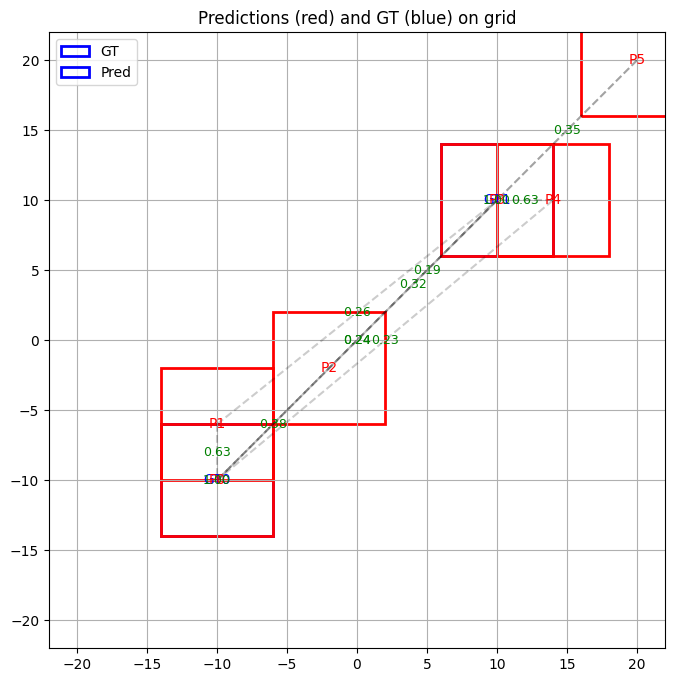

Score matrix (pred x gt):
tensor([[1.0000, 0.2449],
        [0.6282, 0.2588],
        [0.3750, 0.3200],
        [0.2449, 1.0000],
        [0.2301, 0.6282],
        [0.1884, 0.3457]])


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from mmcv.ops.box_iou_rotated import box_iou_rotated
from matplotlib.transforms import Affine2D
# from projects.mmdet3d_plugin.models.utils.misc import convert_3Dbox_to_2D


def rel_depth_err(depths1, depths2):
    '''
    in:
        depths1: Tensor of shape (N,)
        depths2: Tensor of shape (M,)
        depths2: prior as anchor
    out:
        rel_depth_err: (N,M)
    '''
    depths1 = depths1.unsqueeze(-1)
    depths2 = depths2.unsqueeze(0)
    res = 1 - torch.abs(depths2-depths1)/depths2
    return torch.relu(res)

def rel_depth_err_batched(depths1, depths2):
    '''
    in:
        depths1: Tensor of shape (B, N)
        depths2: Tensor of shape (B, M)
        depths2: prior as anchor (denominator)
    out:
        rel_depth_err: Tensor of shape (B, N, M)
    '''
    depths1 = depths1.unsqueeze(2)  # (B, N, 1)
    depths2 = depths2.unsqueeze(1)  # (B, 1, M)
    res = 1 - torch.abs(depths2 - depths1) / depths2.clamp(min=1e-6)
    return torch.relu(res)

def compute_iou(boxes1, boxes2):
    '''
    in:
        boxes1: Tensor of shape (N, 4)
        boxes2: Tensor of shape (M, 4)
    out:
        iou: (N,M)
    '''
    inter_x1 = torch.max(boxes1[:, None, 0], boxes2[:, 0])
    inter_y1 = torch.max(boxes1[:, None, 1], boxes2[:, 1])
    inter_x2 = torch.min(boxes1[:, None, 2], boxes2[:, 2])
    inter_y2 = torch.min(boxes1[:, None, 3], boxes2[:, 3])
    inter_area = (inter_x2 - inter_x1).clamp(0) * (inter_y2 - inter_y1).clamp(0)
    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2 - inter_area
    return inter_area / union_area

def compute_iou_batched(boxes1, boxes2):
    '''
    in:
        boxes1: Tensor of shape (B, N, 4)
        boxes2: Tensor of shape (B, M, 4)
    out:
        iou: Tensor of shape (B, N, M)
    '''

    inter_x1 = torch.max(boxes1[:, :, None, 0], boxes2[:, None, :, 0])  # (B, N, M)
    inter_y1 = torch.max(boxes1[:, :, None, 1], boxes2[:, None, :, 1])
    inter_x2 = torch.min(boxes1[:, :, None, 2], boxes2[:, None, :, 2])
    inter_y2 = torch.min(boxes1[:, :, None, 3], boxes2[:, None, :, 3])
    
    inter_area = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)

    area1 = (boxes1[:, :, 2] - boxes1[:, :, 0]) * (boxes1[:, :, 3] - boxes1[:, :, 1])  # (B, N)
    area2 = (boxes2[:, :, 2] - boxes2[:, :, 0]) * (boxes2[:, :, 3] - boxes2[:, :, 1])  # (B, M)

    union_area = area1[:, :, None] + area2[:, None, :] - inter_area  # (B, N, M)

    return inter_area / union_area.clamp(min=1e-6)

def compute_giou(boxes1, boxes2):
    '''
    in:
        boxes1: Tensor of shape (N, 4)
        boxes2: Tensor of shape (M, 4)
    out:
        giou: Tensor of shape (N, M)
    '''
    inter_x1 = torch.max(boxes1[:, None, 0], boxes2[:, 0])
    inter_y1 = torch.max(boxes1[:, None, 1], boxes2[:, 1])
    inter_x2 = torch.min(boxes1[:, None, 2], boxes2[:, 2])
    inter_y2 = torch.min(boxes1[:, None, 3], boxes2[:, 3])
    inter_area = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union_area = area1[:, None] + area2 - inter_area
    iou = inter_area / union_area.clamp(min=1e-6)

    enc_x1 = torch.min(boxes1[:, None, 0], boxes2[:, 0])
    enc_y1 = torch.min(boxes1[:, None, 1], boxes2[:, 1])
    enc_x2 = torch.max(boxes1[:, None, 2], boxes2[:, 2])
    enc_y2 = torch.max(boxes1[:, None, 3], boxes2[:, 3])
    enc_area = (enc_x2 - enc_x1).clamp(min=0) * (enc_y2 - enc_y1).clamp(min=0)

    giou = iou - (enc_area - union_area) / enc_area.clamp(min=1e-6)
    return giou

def compute_giou_batched(boxes1, boxes2, rescale=True):
    '''
    in:
        boxes1: Tensor of shape (B, N, 4)
        boxes2: Tensor of shape (B, M, 4)
    out:
        giou: Tensor of shape (B, N, M)
    '''
    # Intersection
    inter_x1 = torch.max(boxes1[:, :, None, 0], boxes2[:, None, :, 0])
    inter_y1 = torch.max(boxes1[:, :, None, 1], boxes2[:, None, :, 1])
    inter_x2 = torch.min(boxes1[:, :, None, 2], boxes2[:, None, :, 2])
    inter_y2 = torch.min(boxes1[:, :, None, 3], boxes2[:, None, :, 3])
    inter_area = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)

    # Area
    area1 = (boxes1[:, :, 2] - boxes1[:, :, 0]) * (boxes1[:, :, 3] - boxes1[:, :, 1])  # (B, N)
    area2 = (boxes2[:, :, 2] - boxes2[:, :, 0]) * (boxes2[:, :, 3] - boxes2[:, :, 1])  # (B, M)
    union_area = area1[:, :, None] + area2[:, None, :] - inter_area
    iou = inter_area / union_area.clamp(min=1e-6)

    # Enclosing box
    enc_x1 = torch.min(boxes1[:, :, None, 0], boxes2[:, None, :, 0])
    enc_y1 = torch.min(boxes1[:, :, None, 1], boxes2[:, None, :, 1])
    enc_x2 = torch.max(boxes1[:, :, None, 2], boxes2[:, None, :, 2])
    enc_y2 = torch.max(boxes1[:, :, None, 3], boxes2[:, None, :, 3])
    enc_area = (enc_x2 - enc_x1).clamp(min=0) * (enc_y2 - enc_y1).clamp(min=0)

    giou = iou - (enc_area - union_area) / enc_area.clamp(min=1e-6)
    if rescale:
        # Rescale giou [-1, 1] -> [0, 1]
        giou = (giou + 1) / 2
        giou = torch.clamp(giou, min=0, max=1)
    return giou


'''
Notes:
In the priorhead, make a dict to allow to switch between iou and giou
'''

def depth_aware_iou(boxes1, depths1, boxes2, depths2, gamma=2, ioufunc=compute_iou, depth_err_func=rel_depth_err):
    # Assume boxes1 is propagated and boxes2 is prior
    iou = ioufunc(boxes1, boxes2)
    rel_err = depth_err_func(depths1, depths2)
    return (iou*rel_err)**gamma

def loc_exp_similarity(boxes1, boxes2, std=2):
    '''
    Compute location similarity between 2 set of points
    '''
    assert boxes1.size(0) == boxes2.size(0), 'Pred and GT num are not equal'
    distance = torch.norm(boxes1[..., :2] - boxes2[..., :2], dim=-1) # 2 - get only x,y. Could be changed to 3 (also get z)
    return torch.exp(-distance**2/(std**2)).detach()

def depth_aware_score(pred_bboxes_3d, gt_bboxes_3d, lidar2img, h, w, gamma=2, depth_err_func=rel_depth_err_batched, ioufunc=compute_iou_batched, rescale_strategy=0):
    '''
    Compute depth aware iou score between predicted and ground truth 3D boxes, based on 2D IoU and depth error
    in:
        pred_bboxes_3d: denormalize boxes (N, 9)
        gt_bboxes_3d: (M, 9)
        lidar2img: (n_cam, 4, 4)
        h: height of image
        w: width of image
    out:
        score_matrix: (N,M)
    '''
    pred_bboxes_2d, pred_depths = convert_3Dbox_to_2D(pred_bboxes_3d, lidar2img, h, w)  # (n_cam, N, 4), (n_cam, N)
    gt_bboxes_2d, gt_depths = convert_3Dbox_to_2D(gt_bboxes_3d, lidar2img, h, w)        # (n_cam, M, 4), (n_cam, M)

    # Compute invalid masks: (n_cam, N) and (n_cam, M)
    pred_invalid = (pred_bboxes_2d == -1).all(dim=-1)  # (n_cam, N)
    gt_invalid = (gt_bboxes_2d == -1).all(dim=-1)      # (n_cam, M)

    # Compute depth-aware IoU in batch: (n_cam, N, M)
    scores = depth_aware_iou(pred_bboxes_2d, pred_depths, gt_bboxes_2d, gt_depths, gamma=gamma, ioufunc=ioufunc, depth_err_func=depth_err_func)

    # Mask out invalid boxes: set score to 0 if either pred or gt is invalid in that view
    pred_invalid = pred_invalid.unsqueeze(2)  # (n_cam, N, 1)
    gt_invalid = gt_invalid.unsqueeze(1)      # (n_cam, 1, M)
    mask = (~pred_invalid) & (~gt_invalid)    # (n_cam, N, M)
    scores = scores * mask.float()

    # Take max over views (n_cam, N, M) -> (N, M)
    scores, _ = scores.max(dim=0)
    # print(scores.shape, scores.flatten().topk(3).values)
    if rescale_strategy == 0:
        max_score = scores.max()
        if max_score > 0:
            scores = scores / max_score
    elif rescale_strategy == 1:
        max_score = scores.max()
        if max_score > 0:
            scores = scores / max_score * (max_score ** (-gamma))
    return scores.detach()

# Another scoring method by project boxes on BEV and compute Ro_DIOU (or GDIOU if succeed)
def compute_ro_diou(pred_bboxes, gt_bboxes, rescale=True):
    '''
    in:
        pred_bboxes and gt_bboxes are denormalized boxes
        pred_bboxes: (N, 9) - x,y,z,w,l,h,theta,vx,vy
        gt_bboxes: (M, 9)
    out:
        ro_gd_iou: (N, M) - Ro_DIOU score
    '''
    b1 = torch.stack([pred_bboxes[:, 0], pred_bboxes[:, 1], pred_bboxes[:, 3], pred_bboxes[:, 4], pred_bboxes[:, 6]], dim=-1)
    b2 = torch.stack([gt_bboxes[:, 0], gt_bboxes[:, 1], gt_bboxes[:, 3], gt_bboxes[:, 4], gt_bboxes[:, 6]], dim=-1)
    ro_iou = box_iou_rotated(b1, b2)

    c = (torch.cdist(pred_bboxes[:, :2], gt_bboxes[:, :2], p=2)**2).to(pred_bboxes.device)
    N, M = b1.size(0), b2.size(0)
    x1_min = b1[:, 0].unsqueeze(1).expand(N, M).clone()
    y1_min = b1[:, 1].unsqueeze(1).expand(N, M).clone()
    x2_min = b2[:, 0].unsqueeze(0).expand(N, M).clone()
    y2_min = b2[:, 1].unsqueeze(0).expand(N, M).clone()

    w1 = b1[:, 2].unsqueeze(1)
    l1 = b1[:, 3].unsqueeze(1)
    w2 = b2[:, 2].unsqueeze(0)
    l2 = b2[:, 3].unsqueeze(0)

    x1_left = x1_min - w1 / 2
    x1_right = x1_min + w1 / 2
    y1_top = y1_min - l1 / 2
    y1_bottom = y1_min + l1 / 2

    x2_left = x2_min - w2 / 2
    x2_right = x2_min + w2 / 2
    y2_top = y2_min - l2 / 2
    y2_bottom = y2_min + l2 / 2

    min_x = torch.min(x1_left, x2_left)
    max_x = torch.max(x1_right, x2_right)
    min_y = torch.min(y1_top, y2_top)
    max_y = torch.max(y1_bottom, y2_bottom)

    d = (max_x - min_x) ** 2 + (max_y - min_y) ** 2

    ro_diou = ro_iou - (c / d.clamp(min=1e-6))
    if rescale:
        ro_diou = (ro_diou + 1) / 2
        ro_diou = ro_diou.clamp(min=0, max=1)
    return ro_diou 


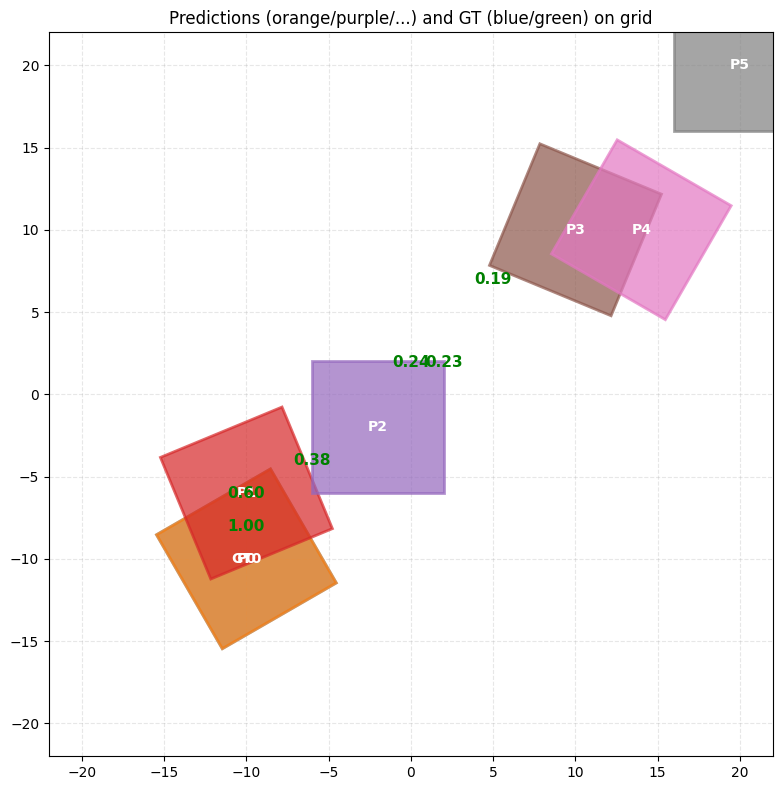

Score matrix (pred x gt):
tensor([[1.0000],
        [0.5987],
        [0.3750],
        [0.2449],
        [0.2301],
        [0.1884]])


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.transforms import Affine2D

def create_boxes_on_grid():
    # GT boxes: 2 boxes
    gt_boxes = torch.tensor([
        [-10, -10, 0, 8, 8, 4, np.pi/6, 0, 0],  # center at (-10, -10), rotated 30 deg
        [10, 10, 0, 8, 8, 4, -np.pi/8, 0, 0],   # center at (10, 10), rotated -22.5 deg
    ], dtype=torch.float32)

    # Pred boxes: 6 cases
    pred_boxes = torch.tensor([
        [-10, -10, 0, 8, 8, 4, np.pi/6, 0, 0],    # perfect overlap with gt0
        [-10, -6, 0, 8, 8, 4, np.pi/8, 0, 0],     # partial overlap with gt0, rotated
        [-2, -2, 0, 8, 8, 4, 0, 0, 0],            # close but not overlap with gt0
        [10, 10, 0, 8, 8, 4, -np.pi/8, 0, 0],     # perfect overlap with gt1
        [14, 10, 0, 8, 8, 4, -np.pi/6, 0, 0],     # partial overlap with gt1, rotated
        [20, 20, 0, 8, 8, 4, 0, 0, 0],            # far from gt1
    ], dtype=torch.float32)
    return pred_boxes, gt_boxes

def plot_boxes(ax, boxes, colors, label_prefix, alpha=0.5, zorder=1):
    for i, box in enumerate(boxes):
        x, y, _, w, l, _, theta, _, _ = box
        color = colors[i % len(colors)]
        rect = patches.Rectangle(
            (x - w/2, y - l/2), w, l,
            linewidth=2, edgecolor=color, facecolor=color, alpha=alpha, zorder=zorder, fill=True
        )
        t = Affine2D().rotate_around(x, y, theta) + ax.transData
        rect.set_transform(t)
        ax.add_patch(rect)
        ax.text(x, y, f'{label_prefix}{i}', color='white', fontsize=10, ha='center', va='center', weight='bold', zorder=3)

def test_and_visualize():
    pred_boxes, gt_boxes = create_boxes_on_grid()
    # Dummy lidar2img, h, w (unused in BEV)
    lidar2img = torch.eye(4).unsqueeze(0)
    h, w = 1, 1

    # Use BEV Ro_DIOU for scoring
    scores = compute_ro_diou(pred_boxes, gt_boxes, rescale=True)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xlim(-22, 22)
    ax.set_ylim(-22, 22)
    ax.set_aspect('equal')
    plot_boxes(ax, gt_boxes, colors=GT_COLORS, label_prefix='GT', alpha=0.5, zorder=1)
    plot_boxes(ax, pred_boxes, colors=PRED_COLORS, label_prefix='P', alpha=0.7, zorder=2)
    ax.set_title('Predictions (orange/purple/...) and GT (blue/green) on grid')

    # Display scores above the midpoint between boxes (no lines)
    for i, pred in enumerate(pred_boxes):
        for j, gt in enumerate(gt_boxes):
            px, py = pred[0], pred[1]
            gx, gy = gt[0], gt[1]
            score = scores[i, j].item()
            mx, my = (px + gx) / 2, (py + gy) / 2
            ax.text(mx, my + 1.5, f'{score:.2f}', color='green', fontsize=11, ha='center', va='bottom', weight='bold', zorder=4)

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Score matrix (pred x gt):")
    print(scores)

if __name__ == "__main__":
    test_and_visualize()


In [17]:
def test(**kwargs):
    a = kwargs.get('a', 1)
    b = kwargs.get('b', 2)
    print(f'Test function called with a={a}, b={b}')

test(c=5)

Test function called with a=1, b=2
